# Multiple Linear Regression - MLR

Linear Regression - Multi Input

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d


In [22]:
def model(X, w, b):
    # y = np.dot(X, w) + b
    y = X @ w + b
    return y

In [23]:
def compute_cost(X, y, w, b): 
    # J function
    m = X.shape[0]
    e = y - model(X, w, b) # (w*x+b)
    total_cost = (1/(2* m)) * sum(e**2)
    return total_cost


In [24]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [25]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [26]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904045996674e-12


In [27]:
def compute_gradient(X, y, w, b): 
    # Number of training examples
    m = X.shape[0] 
    e = model(X, w, b)- y
    dw = (1/m) * X.T @ e
    # dw = (1/m) * np.dot(e, X)
    db = (1/m) * e
    dw = sum(dw)
    db = sum(db)
    return dw, db

In [28]:
from copy import deepcopy
def gradient_descent(x, y, w_in = 0, b_in = 0, alpha = 1, num_iters = 100):
    
    w = deepcopy(w_in)
    b = deepcopy(b_in)
    p_history = [(w, b)]
    cost_history  = [compute_cost(x, y, w, b)] # J
    
    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        p_history.append((w, b))
        cost_history.append(compute_cost(x, y, w, b))
        if i%100 == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:0.2e} ",
                  f"dj_dw: {dw}, dj_db: {db}  ",
                  f"w: {w}, b:{b}")

    return w, b, p_history, cost_history


In [29]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-8
# run gradient descent
w_final, b_final, p_history, cost_history = gradient_descent(X_train ,y_train, initial_w, initial_b, tmp_alpha, iterations)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")


Iteration    0: Cost 4.71e+04  dj_dw: -496223.99999999994, dj_db: -289.99999999999994   w: [0.00496224 0.00496224 0.00496224 0.00496224], b:2.8999999999999993e-06
Iteration  100: Cost 1.01e+03  dj_dw: -38516.64180451362, dj_db: -17.575501696690583   w: [0.1817596 0.1817596 0.1817596 0.1817596], b:0.00010277930108446929
Iteration  200: Cost 7.32e+02  dj_dw: -2989.643870667643, dj_db: 3.5699402011082286   w: [0.19548252 0.19548252 0.19548252 0.19548252], b:0.00010559773708033954
Iteration  300: Cost 7.30e+02  dj_dw: -232.05747929346356, dj_db: 5.211237457377393   w: [0.19654768 0.19654768 0.19654768 0.19654768], b:0.00010088236167404697
Iteration  400: Cost 7.30e+02  dj_dw: -18.015112976325014, dj_db: 5.3386335408253265   w: [0.19663037 0.19663037 0.19663037 0.19663037], b:9.558221641886898e-05
Iteration  500: Cost 7.30e+02  dj_dw: -1.4012601077108684, dj_db: 5.34852143290187   w: [0.19663679 0.19663679 0.19663679 0.19663679], b:9.023668216697012e-05
Iteration  600: Cost 7.30e+02  dj_dw:

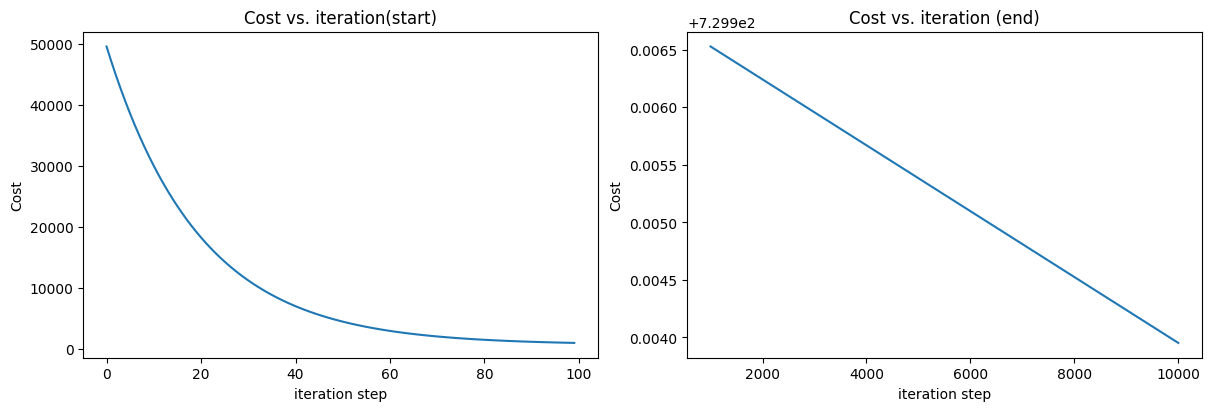

In [30]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(cost_history[:100])
ax2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()